# DCGAN vs LSGAN vs WGAN-GP — MNIST
28x28 digits. Each dataset is trained on **three GAN objectives — DCGAN, LSGAN, WGAN-GP** — then compared on FID / Inception Score, and the winner is promoted for deployment.

WGAN-GP runs ~`N_CRITIC`× more discriminator steps and trains in fp32, so it is the slow one. Training is checkpoint-resumable per architecture, so a disconnect just resumes. To fit a short session, drop an entry from `ARCHITECTURES` and rerun later.

Pipeline-validation dataset; fast. Estimated time on T4: ~1 hour for all three.

## Install dependencies

In [1]:
!pip install -q torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.4 MB/s eta 0:00:00


## Environment & paths (Colab / Kaggle / local)

In [2]:
import os


def detect_env():
    if os.path.exists("/kaggle/working"):
        return "kaggle"
    if os.path.exists("/content"):
        return "colab"
    return "local"


ENV = detect_env()

if ENV == "colab":
    CKPT_DIR = "/content/checkpoints"
    WEIGHTS_DIR = "/content/weights"
    SAMPLES_DIR = "/content/samples"
elif ENV == "kaggle":
    CKPT_DIR = "/kaggle/working/checkpoints"
    WEIGHTS_DIR = "/kaggle/working/weights"
    SAMPLES_DIR = "/kaggle/working/samples"
else:
    CKPT_DIR = "checkpoints"
    WEIGHTS_DIR = "weights"
    SAMPLES_DIR = "samples"

for d in (CKPT_DIR, WEIGHTS_DIR, SAMPLES_DIR):
    os.makedirs(d, exist_ok=True)

PREFIX = "mnist"
print("environment:", ENV, "| checkpoints ->", CKPT_DIR)

environment: colab | checkpoints -> /content/checkpoints


## Imports

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Hyperparameters

In [4]:
NZ = 100
IMG_SIZE = 28
CHANNELS = 1
BATCH_SIZE = 128
LR = 2e-4
BETAS = (0.5, 0.999)

# ---- comparison / training budget ----
ARCHITECTURES = ["dcgan", "lsgan", "wgan_gp"]   # trim to fit a short GPU session
EPOCHS = 30
CKPT_EVERY = 5        # sample + FID + checkpoint cadence
FID_SAMPLES = 2048    # samples per FID/IS estimate
N_CRITIC = 5          # WGAN-GP critic steps per generator step (lower = faster)

## Dataset

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.17MB/s]


## Models — Generator, Discriminator (DCGAN/LSGAN), Critic (WGAN-GP)

In [6]:
import math
import torch.nn as nn


def _gen_config(img_size):
    for init in (4, 7):
        if img_size % init == 0:
            n = img_size // init
            steps = int(math.log2(n))
            if init * (2 ** steps) == img_size:
                return init, steps
    raise ValueError(f"unsupported img_size {img_size}")


class Generator(nn.Module):
    """Latent vector -> image. Self-configures depth from img_size. Shared by all
    three GAN variants. img_size is required."""

    def __init__(self, img_size, nz=100, ngf=64, channels=3):
        super().__init__()
        init_size, steps = _gen_config(img_size)
        cur = ngf * 2 ** max(steps - 1, 0)
        layers = [nn.ConvTranspose2d(nz, cur, init_size, 1, 0, bias=False),
                  nn.BatchNorm2d(cur), nn.ReLU(True)]
        for i in range(steps):
            last = i == steps - 1
            nxt = channels if last else cur // 2
            layers.append(nn.ConvTranspose2d(cur, nxt, 4, 2, 1, bias=False))
            layers += [nn.Tanh()] if last else [nn.BatchNorm2d(nxt), nn.ReLU(True)]
            cur = nxt
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


def _disc_body(img_size, channels, norm):
    """Conv down-sampling stack shared by the DCGAN/LSGAN discriminator and the
    WGAN-GP critic. `norm` is the normalization layer (BatchNorm for DCGAN/LSGAN,
    InstanceNorm for WGAN-GP — BatchNorm breaks the gradient penalty)."""
    init_size, steps = _gen_config(img_size)
    layers = []
    cur, nxt = channels, 64
    for i in range(steps):
        layers.append(nn.Conv2d(cur, nxt, 4, 2, 1, bias=False))
        if i > 0:
            layers.append(norm(nxt))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        cur = nxt
        if i < steps - 1:
            nxt *= 2
    layers.append(nn.Conv2d(cur, 1, init_size, 1, 0, bias=False))
    return nn.Sequential(*layers)


class Discriminator(nn.Module):
    """DCGAN / LSGAN. Outputs a raw score (no Sigmoid) — DCGAN pairs it with
    BCEWithLogitsLoss (autocast-safe), LSGAN with MSELoss."""

    def __init__(self, img_size, channels=3):
        super().__init__()
        self.net = _disc_body(img_size, channels, nn.BatchNorm2d)

    def forward(self, x):
        return self.net(x).view(-1)


class Critic(nn.Module):
    """WGAN-GP critic. InstanceNorm instead of BatchNorm so the gradient penalty
    is well-defined; outputs an unbounded score."""

    def __init__(self, img_size, channels=3):
        super().__init__()
        self.net = _disc_body(img_size, channels, lambda c: nn.InstanceNorm2d(c, affine=True))

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Mixed-precision setup (version-safe)

In [7]:
# Version-safe AMP: new torch.amp API when available, else torch.cuda.amp.
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    _GradScaler("cuda")  # probe (raises on old torch)
    def make_scaler(enabled):
        return _GradScaler("cuda", enabled=enabled)
    def amp_autocast(enabled):
        return _autocast("cuda", enabled=enabled)
    print("AMP API: torch.amp")
except (ImportError, TypeError, RuntimeError):
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(enabled):
        return _GradScaler(enabled=enabled)
    def amp_autocast(enabled):
        return _autocast(enabled=enabled)
    print("AMP API: torch.cuda.amp")

AMP API: torch.amp


## Display helper + real-sample preview

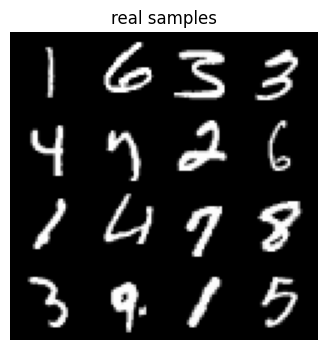

In [8]:
CMAP = "gray" if CHANNELS == 1 else None


def show_grid(img_grid, title=None, save=None, figsize=(4, 4)):
    arr = img_grid.permute(1, 2, 0)
    if CHANNELS == 1:
        arr = arr.squeeze()
    plt.figure(figsize=figsize)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.imshow(arr, cmap=CMAP)
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()


real_batch, _ = next(iter(dataloader))
show_grid(make_grid(real_batch[:16], nrow=4, normalize=True), title="real samples")

## Evaluation metrics — FID & Inception Score

In [9]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore


@torch.no_grad()
def compute_fid_is(gen, n_samples=2048, batch=128):
    """FID (lower better) and Inception Score (higher better) for a generator.
    Inception wants 3-channel [0,1] images; we un-normalize from [-1,1] and
    expand grayscale. FID on MNIST is unconventional but a valid relative signal."""
    fid = FrechetInceptionDistance(normalize=True).to(device)
    iscore = InceptionScore(normalize=True).to(device)
    gen.eval()

    def prep(x):
        x = (x.clamp(-1, 1) + 1) / 2
        return x.repeat(1, 3, 1, 1) if x.size(1) == 1 else x

    seen = 0
    for real, _ in dataloader:
        fid.update(prep(real.to(device)), real=True)
        seen += real.size(0)
        if seen >= n_samples:
            break
    seen = 0
    while seen < n_samples:
        z = torch.randn(batch, NZ, 1, 1, device=device)
        fake = prep(gen(z))
        fid.update(fake, real=False)
        iscore.update(fake)
        seen += batch
    gen.train()
    return fid.compute().item(), iscore.compute()[0].item()

## Training engine (checkpoint-resumable, one function per architecture)

In [10]:
import json


def gradient_penalty(critic, real, fake):
    bs = real.size(0)
    eps = torch.rand(bs, 1, 1, 1, device=real.device)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    scores = critic(interp)
    grads = torch.autograd.grad(
        outputs=scores, inputs=interp, grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True, only_inputs=True)[0]
    grads = grads.reshape(bs, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


def build_models(arch):
    G = Generator(img_size=IMG_SIZE, nz=NZ, channels=CHANNELS).to(device)
    D = (Critic if arch == "wgan_gp" else Discriminator)(img_size=IMG_SIZE, channels=CHANNELS).to(device)
    G.apply(weights_init)
    D.apply(weights_init)
    return G, D


def train_gan(arch, epochs, checkpoint_every=5, fid_samples=2048, n_critic=5, gp_lambda=10.0):
    """Train one architecture end-to-end with checkpoint-resume. Saves per-arch
    final + best-FID generators, samples, and history. Returns the history dict."""
    ckpt_path = os.path.join(CKPT_DIR, f"{PREFIX}_{arch}_checkpoint.pth")
    best_path = os.path.join(WEIGHTS_DIR, f"{PREFIX}_{arch}_generator_best.pth")
    final_path = os.path.join(WEIGHTS_DIR, f"{PREFIX}_{arch}_generator.pth")
    hist_path = os.path.join(SAMPLES_DIR, f"{PREFIX}_{arch}_history.json")

    G, D = build_models(arch)
    betas = (0.5, 0.9) if arch == "wgan_gp" else BETAS
    optG = torch.optim.Adam(G.parameters(), lr=LR, betas=betas)
    optD = torch.optim.Adam(D.parameters(), lr=LR, betas=betas)
    use_amp = (device.type == "cuda") and (arch != "wgan_gp")  # GP needs fp32 double-backward
    scalerG, scalerD = make_scaler(use_amp), make_scaler(use_amp)
    fixed_noise = torch.randn(16, NZ, 1, 1, device=device)

    history = {"g_loss": [], "d_loss": [], "dx": [], "dgz": [], "fid": []}
    start_epoch, best_fid = 0, float("inf")
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location=device)
        G.load_state_dict(ck["G"]); D.load_state_dict(ck["D"])
        optG.load_state_dict(ck["optG"]); optD.load_state_dict(ck["optD"])
        start_epoch, best_fid, history = ck["epoch"] + 1, ck["best_fid"], ck["history"]
        fixed_noise = ck["fixed_noise"].to(device)
        print(f"[{arch}] resumed at epoch {start_epoch} (best FID {best_fid:.2f})")

    if start_epoch >= epochs:
        print(f"[{arch}] already complete — skipping")
        return history

    bce, mse = torch.nn.BCEWithLogitsLoss(), torch.nn.MSELoss()

    for epoch in range(start_epoch, epochs):
        gl = dl = dx = dgz = 0.0
        nb = 0
        for real, _ in dataloader:
            real = real.to(device)
            bs = real.size(0)

            if arch == "wgan_gp":
                for _ in range(n_critic):
                    fake = G(torch.randn(bs, NZ, 1, 1, device=device)).detach()
                    d_real, d_fake = D(real).mean(), D(fake).mean()
                    lossD = d_fake - d_real + gp_lambda * gradient_penalty(D, real.data, fake.data)
                    optD.zero_grad(); lossD.backward(); optD.step()
                fake = G(torch.randn(bs, NZ, 1, 1, device=device))
                lossG = -D(fake).mean()
                optG.zero_grad(); lossG.backward(); optG.step()
                dx += d_real.item(); dgz += d_fake.item()
            else:
                optD.zero_grad()
                with amp_autocast(use_amp):
                    fake = G(torch.randn(bs, NZ, 1, 1, device=device))
                    out_real, out_fake = D(real), D(fake.detach())
                    if arch == "dcgan":
                        lossD = bce(out_real, torch.full((bs,), 0.9, device=device)) + \
                                bce(out_fake, torch.zeros(bs, device=device))
                    else:  # lsgan
                        lossD = mse(out_real, torch.ones(bs, device=device)) + \
                                mse(out_fake, torch.zeros(bs, device=device))
                scalerD.scale(lossD).backward(); scalerD.step(optD); scalerD.update()

                optG.zero_grad()
                with amp_autocast(use_amp):
                    out = D(fake)
                    tgt = torch.ones(bs, device=device)
                    lossG = bce(out, tgt) if arch == "dcgan" else mse(out, tgt)
                scalerG.scale(lossG).backward(); scalerG.step(optG); scalerG.update()
                dx += torch.sigmoid(out_real.detach()).mean().item()
                dgz += torch.sigmoid(out_fake.detach()).mean().item()

            gl += lossG.item(); dl += lossD.item(); nb += 1

        history["g_loss"].append(gl / nb); history["d_loss"].append(dl / nb)
        history["dx"].append(dx / nb); history["dgz"].append(dgz / nb)
        extra = "" if arch == "wgan_gp" else f"  D(x)={dx / nb:.3f}  D(G(z))={dgz / nb:.3f}"
        print(f"[{arch}] epoch {epoch + 1}/{epochs}  loss_g={gl / nb:.3f}  loss_d={dl / nb:.3f}{extra}")

        if (epoch + 1) == 1 or (epoch + 1) % checkpoint_every == 0 or (epoch + 1) == epochs:
            G.eval()
            with torch.no_grad():
                samp = G(fixed_noise).cpu()
            G.train()
            show_grid(make_grid(samp, nrow=4, normalize=True), title=f"{arch} — epoch {epoch + 1}",
                      save=os.path.join(SAMPLES_DIR, f"{PREFIX}_{arch}_epoch{epoch + 1:03d}.png"))
            fid, isc = compute_fid_is(G, fid_samples)
            history["fid"].append((epoch + 1, fid, isc))
            print(f"    [{arch}] FID={fid:.2f}  IS={isc:.2f}")
            if fid < best_fid:
                best_fid = fid
                torch.save(G.state_dict(), best_path)
            torch.save({"epoch": epoch, "best_fid": best_fid, "history": history,
                        "G": G.state_dict(), "D": D.state_dict(),
                        "optG": optG.state_dict(), "optD": optD.state_dict(),
                        "fixed_noise": fixed_noise.cpu()}, ckpt_path)
            json.dump(history, open(hist_path, "w"))

    torch.save(G.state_dict(), final_path)
    print(f"[{arch}] done — final {final_path} | best (FID {best_fid:.2f}) {best_path}")
    return history

## Train all architectures

training dcgan
[dcgan] epoch 1/30  loss_g=2.450  loss_d=0.606  D(x)=0.778  D(G(z))=0.139


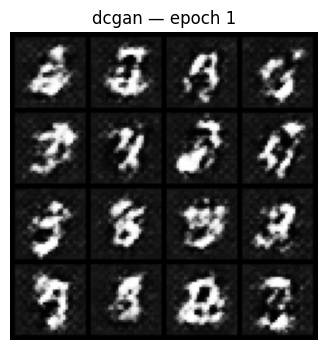

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 364MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


    [dcgan] FID=188.37  IS=1.87
[dcgan] epoch 2/30  loss_g=2.317  loss_d=0.649  D(x)=0.753  D(G(z))=0.147
[dcgan] epoch 3/30  loss_g=2.143  loss_d=0.696  D(x)=0.733  D(G(z))=0.166
[dcgan] epoch 4/30  loss_g=1.921  loss_d=0.778  D(x)=0.697  D(G(z))=0.203
[dcgan] epoch 5/30  loss_g=1.788  loss_d=0.899  D(x)=0.660  D(G(z))=0.237


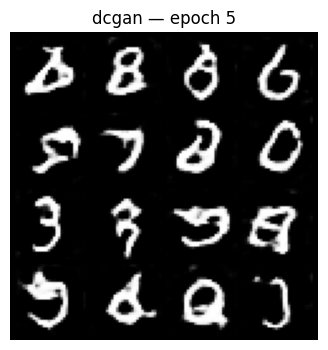

    [dcgan] FID=49.39  IS=1.98
[dcgan] epoch 6/30  loss_g=1.713  loss_d=0.877  D(x)=0.658  D(G(z))=0.242
[dcgan] epoch 7/30  loss_g=1.745  loss_d=0.880  D(x)=0.660  D(G(z))=0.240
[dcgan] epoch 8/30  loss_g=1.742  loss_d=0.888  D(x)=0.654  D(G(z))=0.244
[dcgan] epoch 9/30  loss_g=1.778  loss_d=0.867  D(x)=0.666  D(G(z))=0.234
[dcgan] epoch 10/30  loss_g=1.847  loss_d=0.848  D(x)=0.673  D(G(z))=0.227


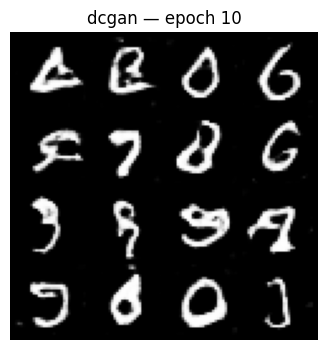

    [dcgan] FID=27.96  IS=2.18
[dcgan] epoch 11/30  loss_g=1.898  loss_d=0.844  D(x)=0.677  D(G(z))=0.223
[dcgan] epoch 12/30  loss_g=1.859  loss_d=0.845  D(x)=0.672  D(G(z))=0.227
[dcgan] epoch 13/30  loss_g=1.918  loss_d=0.857  D(x)=0.676  D(G(z))=0.221
[dcgan] epoch 14/30  loss_g=1.945  loss_d=0.819  D(x)=0.685  D(G(z))=0.215
[dcgan] epoch 15/30  loss_g=1.969  loss_d=0.823  D(x)=0.687  D(G(z))=0.213


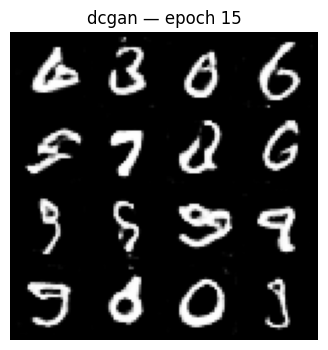

    [dcgan] FID=24.03  IS=2.14
[dcgan] epoch 16/30  loss_g=1.999  loss_d=0.817  D(x)=0.690  D(G(z))=0.210
[dcgan] epoch 17/30  loss_g=2.037  loss_d=0.801  D(x)=0.695  D(G(z))=0.205
[dcgan] epoch 18/30  loss_g=2.095  loss_d=0.804  D(x)=0.698  D(G(z))=0.200
[dcgan] epoch 19/30  loss_g=2.086  loss_d=0.787  D(x)=0.701  D(G(z))=0.199
[dcgan] epoch 20/30  loss_g=2.119  loss_d=0.777  D(x)=0.705  D(G(z))=0.195


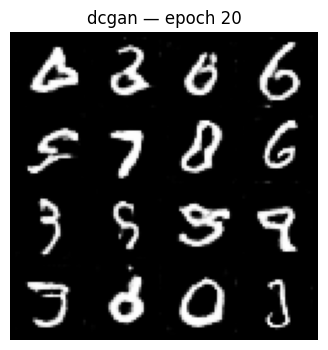

    [dcgan] FID=23.46  IS=2.05
[dcgan] epoch 21/30  loss_g=2.146  loss_d=0.770  D(x)=0.708  D(G(z))=0.191
[dcgan] epoch 22/30  loss_g=2.181  loss_d=0.774  D(x)=0.708  D(G(z))=0.191
[dcgan] epoch 23/30  loss_g=2.193  loss_d=0.759  D(x)=0.712  D(G(z))=0.187
[dcgan] epoch 24/30  loss_g=2.196  loss_d=0.763  D(x)=0.713  D(G(z))=0.186
[dcgan] epoch 25/30  loss_g=2.246  loss_d=0.740  D(x)=0.720  D(G(z))=0.181


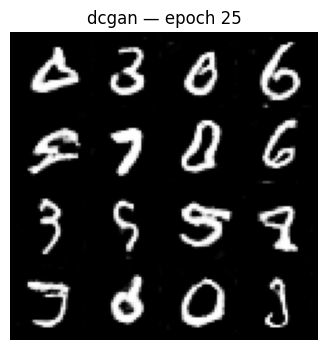

    [dcgan] FID=23.16  IS=2.08
[dcgan] epoch 26/30  loss_g=2.274  loss_d=0.737  D(x)=0.721  D(G(z))=0.179
[dcgan] epoch 27/30  loss_g=2.248  loss_d=0.764  D(x)=0.717  D(G(z))=0.184
[dcgan] epoch 28/30  loss_g=2.288  loss_d=0.730  D(x)=0.724  D(G(z))=0.175
[dcgan] epoch 29/30  loss_g=2.296  loss_d=0.732  D(x)=0.725  D(G(z))=0.175
[dcgan] epoch 30/30  loss_g=2.311  loss_d=0.739  D(x)=0.725  D(G(z))=0.174


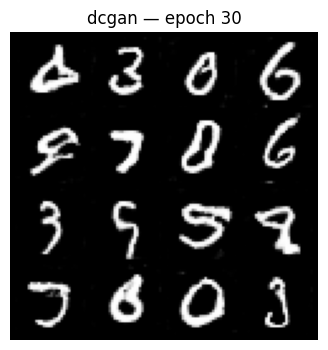

    [dcgan] FID=22.33  IS=2.06
[dcgan] done — final /content/weights/mnist_dcgan_generator.pth | best (FID 22.33) /content/weights/mnist_dcgan_generator_best.pth
training lsgan
[lsgan] epoch 1/30  loss_g=1.082  loss_d=0.323  D(x)=0.706  D(G(z))=0.528


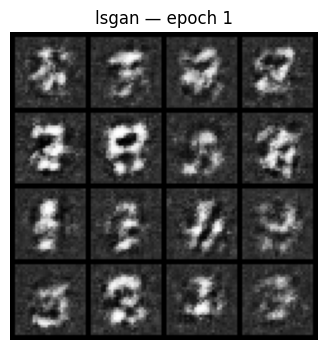

    [lsgan] FID=257.01  IS=2.22
[lsgan] epoch 2/30  loss_g=0.901  loss_d=0.133  D(x)=0.711  D(G(z))=0.522
[lsgan] epoch 3/30  loss_g=0.833  loss_d=0.197  D(x)=0.700  D(G(z))=0.534
[lsgan] epoch 4/30  loss_g=0.803  loss_d=0.146  D(x)=0.700  D(G(z))=0.535
[lsgan] epoch 5/30  loss_g=0.808  loss_d=0.346  D(x)=0.683  D(G(z))=0.547


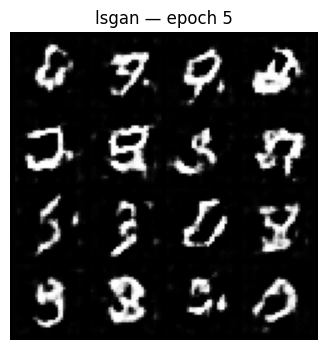

    [lsgan] FID=102.17  IS=1.78
[lsgan] epoch 6/30  loss_g=0.551  loss_d=0.258  D(x)=0.667  D(G(z))=0.573
[lsgan] epoch 7/30  loss_g=0.642  loss_d=0.259  D(x)=0.676  D(G(z))=0.562
[lsgan] epoch 8/30  loss_g=0.630  loss_d=0.282  D(x)=0.673  D(G(z))=0.565
[lsgan] epoch 9/30  loss_g=0.536  loss_d=0.402  D(x)=0.654  D(G(z))=0.585
[lsgan] epoch 10/30  loss_g=0.543  loss_d=0.303  D(x)=0.662  D(G(z))=0.578


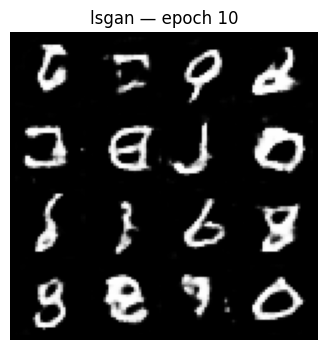

    [lsgan] FID=37.44  IS=2.15
[lsgan] epoch 11/30  loss_g=0.594  loss_d=0.308  D(x)=0.667  D(G(z))=0.572
[lsgan] epoch 12/30  loss_g=0.535  loss_d=0.343  D(x)=0.659  D(G(z))=0.581
[lsgan] epoch 13/30  loss_g=0.551  loss_d=0.385  D(x)=0.657  D(G(z))=0.582
[lsgan] epoch 14/30  loss_g=0.540  loss_d=0.314  D(x)=0.661  D(G(z))=0.579
[lsgan] epoch 15/30  loss_g=0.600  loss_d=0.335  D(x)=0.665  D(G(z))=0.573


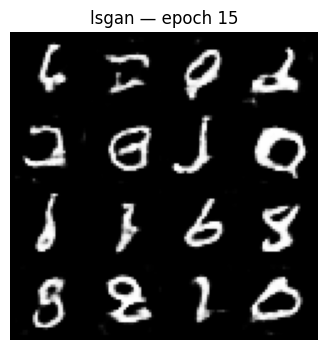

    [lsgan] FID=28.21  IS=2.15
[lsgan] epoch 16/30  loss_g=0.570  loss_d=0.308  D(x)=0.664  D(G(z))=0.575
[lsgan] epoch 17/30  loss_g=0.599  loss_d=0.320  D(x)=0.666  D(G(z))=0.572
[lsgan] epoch 18/30  loss_g=0.600  loss_d=0.285  D(x)=0.669  D(G(z))=0.570
[lsgan] epoch 19/30  loss_g=0.614  loss_d=0.321  D(x)=0.667  D(G(z))=0.571
[lsgan] epoch 20/30  loss_g=0.585  loss_d=0.294  D(x)=0.667  D(G(z))=0.572


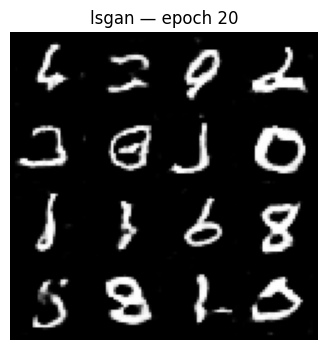

    [lsgan] FID=25.32  IS=2.11
[lsgan] epoch 21/30  loss_g=0.663  loss_d=0.584  D(x)=0.652  D(G(z))=0.583
[lsgan] epoch 22/30  loss_g=0.488  loss_d=0.345  D(x)=0.654  D(G(z))=0.587
[lsgan] epoch 23/30  loss_g=0.532  loss_d=0.338  D(x)=0.659  D(G(z))=0.582
[lsgan] epoch 24/30  loss_g=0.571  loss_d=0.327  D(x)=0.663  D(G(z))=0.576
[lsgan] epoch 25/30  loss_g=0.596  loss_d=0.309  D(x)=0.666  D(G(z))=0.573


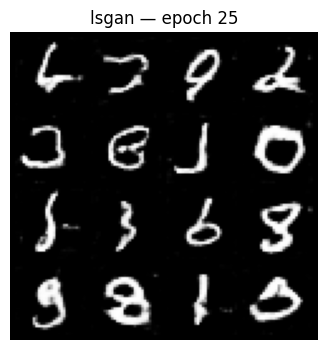

    [lsgan] FID=29.10  IS=2.07
[lsgan] epoch 26/30  loss_g=0.614  loss_d=0.300  D(x)=0.669  D(G(z))=0.570
[lsgan] epoch 27/30  loss_g=0.621  loss_d=0.290  D(x)=0.670  D(G(z))=0.568
[lsgan] epoch 28/30  loss_g=0.631  loss_d=0.292  D(x)=0.671  D(G(z))=0.568
[lsgan] epoch 29/30  loss_g=0.635  loss_d=0.281  D(x)=0.672  D(G(z))=0.566
[lsgan] epoch 30/30  loss_g=0.637  loss_d=0.285  D(x)=0.672  D(G(z))=0.566


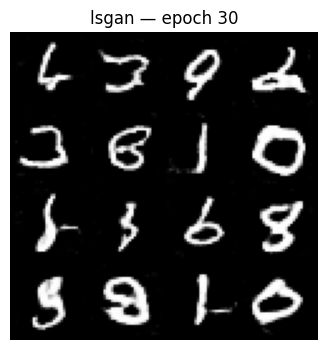

    [lsgan] FID=24.51  IS=2.09
[lsgan] done — final /content/weights/mnist_lsgan_generator.pth | best (FID 24.51) /content/weights/mnist_lsgan_generator_best.pth
training wgan_gp
[wgan_gp] epoch 1/30  loss_g=-12.809  loss_d=-6.306


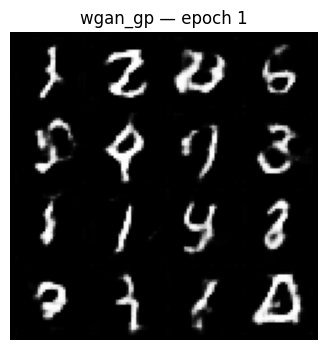

    [wgan_gp] FID=62.08  IS=2.09
[wgan_gp] epoch 2/30  loss_g=-11.311  loss_d=-3.901
[wgan_gp] epoch 3/30  loss_g=-13.554  loss_d=-3.296
[wgan_gp] epoch 4/30  loss_g=-15.357  loss_d=-3.017
[wgan_gp] epoch 5/30  loss_g=-16.778  loss_d=-2.811


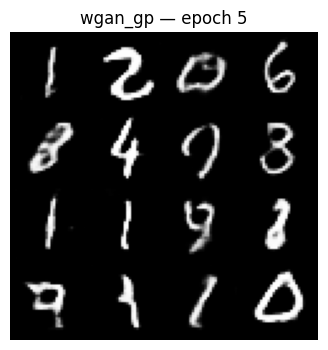

    [wgan_gp] FID=27.44  IS=2.24
[wgan_gp] epoch 6/30  loss_g=-16.980  loss_d=-2.655
[wgan_gp] epoch 7/30  loss_g=-17.144  loss_d=-2.539
[wgan_gp] epoch 8/30  loss_g=-16.958  loss_d=-2.454
[wgan_gp] epoch 9/30  loss_g=-17.327  loss_d=-2.371
[wgan_gp] epoch 10/30  loss_g=-17.065  loss_d=-2.287


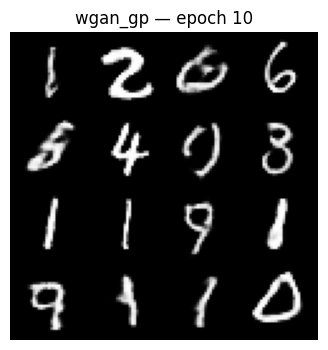

    [wgan_gp] FID=19.80  IS=2.25
[wgan_gp] epoch 11/30  loss_g=-17.010  loss_d=-2.236
[wgan_gp] epoch 12/30  loss_g=-17.124  loss_d=-2.198
[wgan_gp] epoch 13/30  loss_g=-16.822  loss_d=-2.150
[wgan_gp] epoch 14/30  loss_g=-16.444  loss_d=-2.083
[wgan_gp] epoch 15/30  loss_g=-15.947  loss_d=-2.080


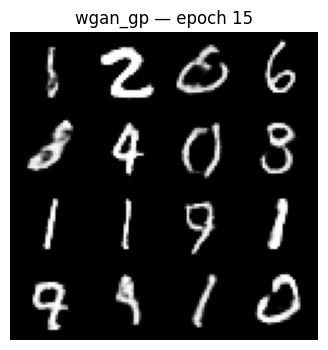

    [wgan_gp] FID=17.31  IS=2.27
[wgan_gp] epoch 16/30  loss_g=-15.700  loss_d=-2.019
[wgan_gp] epoch 17/30  loss_g=-15.514  loss_d=-2.000
[wgan_gp] epoch 18/30  loss_g=-15.588  loss_d=-1.969
[wgan_gp] epoch 19/30  loss_g=-15.521  loss_d=-1.945
[wgan_gp] epoch 20/30  loss_g=-15.385  loss_d=-1.916


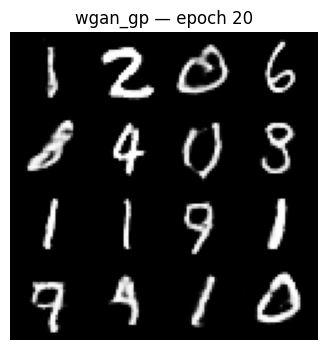

    [wgan_gp] FID=16.72  IS=2.21
[wgan_gp] epoch 21/30  loss_g=-15.417  loss_d=-1.884
[wgan_gp] epoch 22/30  loss_g=-15.477  loss_d=-1.868
[wgan_gp] epoch 23/30  loss_g=-15.495  loss_d=-1.852
[wgan_gp] epoch 24/30  loss_g=-15.242  loss_d=-1.817
[wgan_gp] epoch 25/30  loss_g=-14.987  loss_d=-1.786


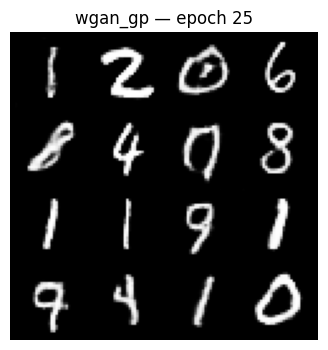

    [wgan_gp] FID=15.62  IS=2.27
[wgan_gp] epoch 26/30  loss_g=-15.005  loss_d=-1.774
[wgan_gp] epoch 27/30  loss_g=-14.556  loss_d=-1.760
[wgan_gp] epoch 28/30  loss_g=-14.461  loss_d=-1.752
[wgan_gp] epoch 29/30  loss_g=-14.459  loss_d=-1.727
[wgan_gp] epoch 30/30  loss_g=-14.122  loss_d=-1.725


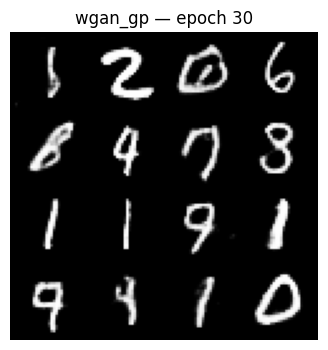

    [wgan_gp] FID=15.93  IS=2.24
[wgan_gp] done — final /content/weights/mnist_wgan_gp_generator.pth | best (FID 15.62) /content/weights/mnist_wgan_gp_generator_best.pth


In [11]:
histories = {}
for arch in ARCHITECTURES:
    print("=" * 60, f"\ntraining {arch}\n" + "=" * 60)
    histories[arch] = train_gan(arch, EPOCHS, checkpoint_every=CKPT_EVERY,
                                fid_samples=FID_SAMPLES, n_critic=N_CRITIC)

## Architecture comparison + pick the winner

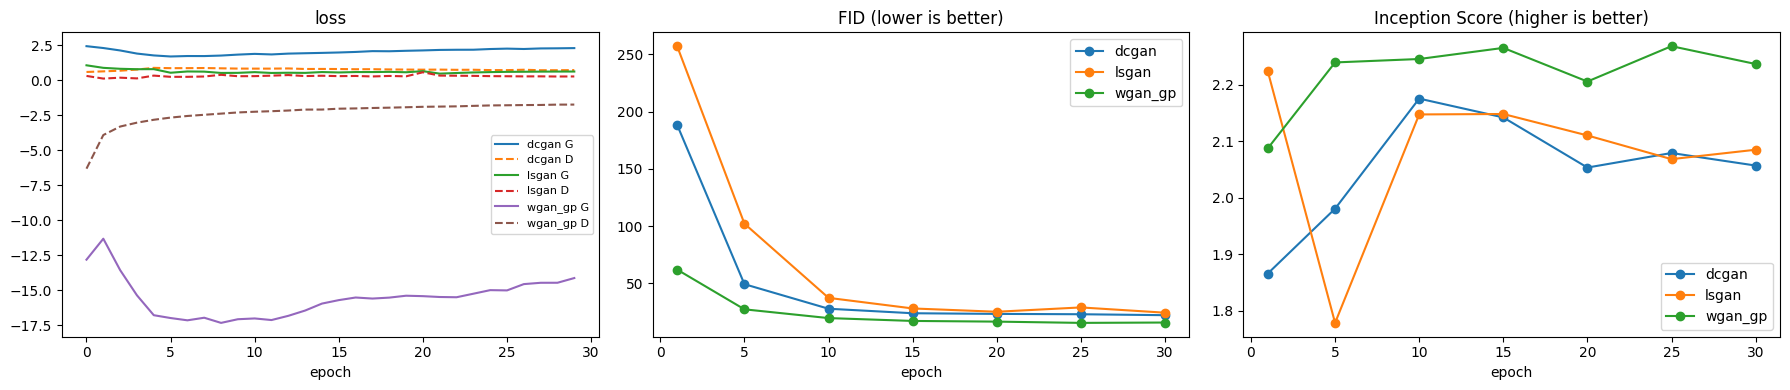

architecture    best FID  final FID  final IS
dcgan              22.33      22.33      2.06
lsgan              24.51      24.51      2.09
wgan_gp            15.62      15.93      2.24

WINNER: wgan_gp  (best FID 15.62)
deployment default -> mnist_generator.pth (wgan_gp); winners.json updated


In [12]:
# ---- overlay curves ----
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for arch in ARCHITECTURES:
    h = histories[arch]
    ax[0].plot(h["g_loss"], label=f"{arch} G")
    ax[0].plot(h["d_loss"], "--", label=f"{arch} D")
    if h["fid"]:
        ep, fids, iss = zip(*h["fid"])
        ax[1].plot(ep, fids, marker="o", label=arch)
        ax[2].plot(ep, iss, marker="o", label=arch)
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=8)
ax[1].set_title("FID (lower is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].set_title("Inception Score (higher is better)"); ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()

# ---- summary table + winner (lowest best-FID) ----
print(f"{'architecture':14}{'best FID':>10}{'final FID':>11}{'final IS':>10}")
winner, winner_fid = None, float("inf")
for arch in ARCHITECTURES:
    h = histories[arch]["fid"]
    if not h:
        continue
    fids = [f for _, f, _ in h]
    best = min(fids)
    print(f"{arch:14}{best:10.2f}{fids[-1]:11.2f}{h[-1][2]:10.2f}")
    if best < winner_fid:
        winner, winner_fid = arch, best
print(f"\nWINNER: {winner}  (best FID {winner_fid:.2f})")

# ---- promote winner to the deployment weight + record it ----
import shutil
shutil.copy(os.path.join(WEIGHTS_DIR, f"{PREFIX}_{winner}_generator_best.pth"),
            os.path.join(WEIGHTS_DIR, f"{PREFIX}_generator.pth"))
wp = os.path.join(WEIGHTS_DIR, "winners.json")
winners = json.load(open(wp)) if os.path.exists(wp) else {}
winners[PREFIX] = winner
json.dump(winners, open(wp, "w"))
print(f"deployment default -> {PREFIX}_generator.pth ({winner}); winners.json updated")

## Best-generator grids, side by side

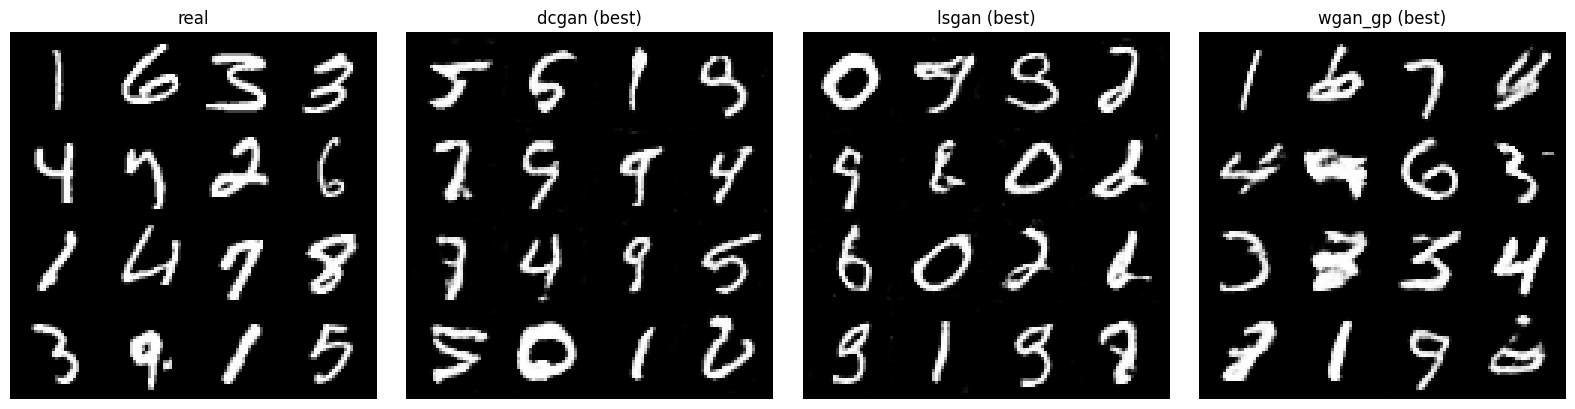

In [13]:
fig, axes = plt.subplots(1, len(ARCHITECTURES) + 1, figsize=(4 * (len(ARCHITECTURES) + 1), 4))
axes[0].imshow(make_grid(real_batch[:16], nrow=4, normalize=True).permute(1, 2, 0).squeeze(), cmap=CMAP)
axes[0].set_title("real"); axes[0].axis("off")
for ax, arch in zip(axes[1:], ARCHITECTURES):
    g = Generator(img_size=IMG_SIZE, nz=NZ, channels=CHANNELS).to(device)
    g.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, f"{PREFIX}_{arch}_generator_best.pth"),
                                 map_location=device))
    g.eval()
    with torch.no_grad():
        samp = g(torch.randn(16, NZ, 1, 1, device=device)).cpu()
    ax.imshow(make_grid(samp, nrow=4, normalize=True).permute(1, 2, 0).squeeze(), cmap=CMAP)
    ax.set_title(f"{arch} (best)"); ax.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(SAMPLES_DIR, f"{PREFIX}_architecture_comparison.png")); plt.show()